In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans
import re
import copy

import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [2]:
## 매 첫 클러스터링 이후 Kernel restart
# PRNG (난수발생기) 고정을 위함
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["PYTHONHASHSEED"] = "0"

In [3]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [4]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [5]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [4]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [5]:
## Configs
base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
# out = f'{base}/Clustering/M01_Main'
out = f'{base}/Clustering/M13/GMM/2_SurvOnly/4_OR'
ipt = f'{base}/Dataset'
SEED = 64

In [6]:
# CLUSTERING :: DATA IMPORT

# Data import
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M05-alive.csv")
df = pd.read_csv(f"{ipt}/knn_prep-fin_M05-alive.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
df

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (22,23) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,0,1,0,0,0,1,0,0,0
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,0,1,0,0,0,1,0,0,0
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,0,1,0,0,0,1,0,0,0
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,0,1,0,0,0,1,0,0,0
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,0,1,0,0,0,1,0,0,0


In [7]:
## 특정 칼럼의 값을 가진 인원만 사용

col_name1 = 'iperr_2'
col_name2 = 'ntet_1'
# col_name = 'iperr_2'
value = 1

df = df[(df[col_name1] == value) | (df[col_name2] == value)]    # 'OR' condition
# df = df[df[col_name] == value]
num_rows = df.shape[0]
num_cols = df.shape[1]
summary_df = pd.DataFrame({
    'n_participants': [num_rows],
    'n_features': [num_cols]
})

# file_name = col_name.split('_')[0] + '_Pos_DataSummary'
# summary_df.to_csv(f"{out}/{file_name}.csv", index=False)
# print(f"Data summary has been saved: {out}/{file_name}.csv")

df

,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
44,1,2013-07-22,2013-07-22,2013-07-22,1.0,5.0,990,32,1,0,...,0,0,1,0,0,0,1,0,0,0
109,0,2013-07-21,2013-07-21,2013-08-03,3.0,4.0,922,38,3,2,...,1,0,0,1,0,0,0,1,0,0
134,0,2013-11-25,2013-11-25,2013-11-25,5.0,8.0,980,34,3,0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20238,0,2022-07-26,2022-07-26,2022-07-28,7.0,9.0,740,30,1,0,...,0,0,0,1,0,0,0,0,1,0
20247,1,2022-07-20,2022-07-20,2022-07-20,7.0,9.0,1410,30,1,0,...,0,0,1,0,0,0,1,0,0,0
20262,0,2022-01-07,2022-01-07,2022-01-07,6.0,8.0,1090,32,1,0,...,0,0,0,0,0,1,1,0,0,0


In [8]:

drop_cols = []
datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
                ]
drop_cols += datetime_cols
df = df.drop(columns=list(drop_cols))

tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
                                                    , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
                                                    , 'NTET_day', 'PDA_7d_NTET'
                                                    , 'invfpod'
                                                    , 'iperr', 'iperroy'
                                                    , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
                                                    , 'IPERR_day', 'PDA_7d_IPERR'
                                                    , 'PDA_7d_IPERRorNTET'
                                                    , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
                                                   ]
            or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
                                                         , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
                                                         , 'NTET_day', 'PDA_7d_NTET'
                                                         , 'invfpod'
                                                         , 'iperr', 'iperroy'
                                                         , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
                                                         , 'IPERR_day', 'PDA_7d_IPERR'
                                                         , 'PDA_7d_IPERRorNTET'
                                                         , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
                                                        ])
           ]
data = df.drop(columns=['death_label'] + list(tgt_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

df_scd['death_label'] = df['death_label']

df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
3,0.893117,1.034192,0.325095,1.521074,-1.692109,-0.817740,-0.646239,0.351421,-0.327271,1.395323,...,1.033106,-0.425815,-0.754548,-2.260078,12.351981,-0.431896,-1.174018,1.174018,0.0,0
4,0.893117,-0.016137,-0.784583,1.154606,0.556645,1.793361,0.707966,2.044964,-0.327271,0.770313,...,1.033106,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
44,0.893117,-1.591631,-0.784583,0.238436,-0.342857,-0.817740,-0.646239,0.492550,-0.327271,0.353640,...,1.033106,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
109,-1.119674,-0.541302,-1.339421,-0.010762,1.006396,0.922994,2.062171,0.633678,-0.327271,-0.896379,...,-0.967955,2.348436,-0.754548,-2.260078,-0.080959,2.315372,-1.174018,1.174018,0.0,0
134,-1.119674,0.509027,0.879934,0.201789,0.106894,0.922994,-0.646239,0.492550,-0.327271,-0.479706,...,-0.967955,2.348436,-0.754548,-2.260078,-0.080959,2.315372,-1.174018,1.174018,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20238,-1.119674,1.559356,1.434773,-0.677734,-0.792608,-0.817740,-0.646239,-0.495350,-0.327271,-0.271370,...,1.033106,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
20247,0.893117,1.559356,1.434773,1.777602,-0.792608,-0.817740,-0.646239,1.198193,-0.327271,1.603659,...,-0.967955,-0.425815,1.325296,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
20262,-1.119674,1.034192,0.879934,0.604904,-0.342857,-0.817740,-0.646239,0.633678,-0.327271,0.353640,...,-0.967955,2.348436,-0.754548,0.442463,-0.080959,-0.431896,-1.174018,1.174018,0.0,0


In [9]:
print(len(drop_cols))
print(len(datetime_cols))
print(len(tgt_cols))

14
14
30


In [10]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 6.          4.          1.          3.          5.          2.
  9.          7.          4.75271096  0.          8.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 7.          5.          4.          8.          6.          3.
 10.          2.          6.92736054  9.          0.          1.        ]
----------------------------------------
칼럼 이름: bwei
데이터 타입: int64
유니크한 값:
[1340 1240  990  922  980 1460  770 1128 1200  690  810 1490 1060 1150
 1420 1270  890  710 1370  780  875  880  560  660 1430  720  540  900
 1010  850 1000  650  670  500 1130  550 1070  932  570  830 1040 1330
 1100  790  870  930  849 1110 1260  750  630  860 1030  950  840 1050
  886  946 1090 1380 1360 1170  835  820 1290 1180 1400  789 1305  490
 1020  590  680  910  410  955  970  700 1410  800 1080  495 1120  530
  760 1250  740  6

데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: pmirnsg_0
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: pmirnsg_1+
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: efyn
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: inhg_0
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: inhg_1
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: inhg_2+
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: inhg_3+
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: bdp
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: bdp_Moderate+
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: ga
데이터 타입: float64
유니크한 값:
[29.2857 27.2857 27.5714 26.7143 26.2857 28.8571 29.8571 26.5714 30.2857
 24.1429 24.7143 33.7143 32.7143 31.5714 29.4286 27.8571 29.     2

In [11]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
bwei,0,0.0,208
mage,0,0.0,31
...,...,...,...
iperr_4,0,0.0,2
iperroy_1,0,0.0,2
iperroy_4,0,0.0,2
iperroy_3,0,0.0,2


In [12]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
bwei,0,0.0,208
mage,0,0.0,31
...,...,...,...
pvl_2,0,0.0,2
seps_1,0,0.0,2
seps_2,0,0.0,2
seps_3,0,0.0,1


In [13]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: float64
유니크한 값:
[ 0.8931175  -1.11967351]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 1.03419177 -0.01613722 -1.5916307  -0.54130171  0.50902727 -1.06646621
  2.60968525  1.55935626  0.37915985 -2.11679519  2.08452075  3.13484974]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 0.32509512 -0.78458252 -1.33942134  0.87993394 -0.2297437  -1.89426016
  1.98961159 -2.44909898  0.28479193  1.43477276 -3.55877663 -3.0039378 ]
----------------------------------------
칼럼 이름: bwei
데이터 타입: float64
유니크한 값:
[ 1.52107421e+00  1.15460616e+00  2.38436043e-01 -1.07622291e-02
  2.01789238e-01  1.96083586e+00 -5.67793661e-01  7.44161948e-01
  1.00801894e+00 -8.60968098e-01 -4.21206442e-01  2.07077628e+00
  4.94963676e-01  8.24784918e-01  1.81424865e+00  1.26454657e+00
 -1.28032004e-01 -7.87674489e-01  1.63101462e+00 -5.31146856e-01
 -1.83002211e-01 -1.64678809e-01 -1.33737656e+00 -9.70908513e-01
  1.85089545e+

In [14]:
# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
print("[1-1, IPERR POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
print("[1-2, NTET POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print()


# # 생존과 사망 비율 계산 (%)
# death_label_ratio = df['death_label'].value_counts(normalize=True) * 100
# # 생존(0)과 사망(1) 비율 각각 출력
# survived_ratio = death_label_ratio[0]  # 생존 비율
# died_ratio = death_label_ratio[1]      # 사망 비율
# print("[2]")
# print("[df_scd (Processed df)]")
# print(f"Survived (0): {survived_ratio:.2f}%")
# print(f"Survived / Total : {len(df[df['death_label'] == 0])} / {len(df['death_label'])}")
# print("&")
# print(f"Died (1): {died_ratio:.2f}%")
# print(f"Death / Total : {len(df[df['death_label'] == 1])} / {len(df['death_label'])}")
# print()


## IPERR + NTET BOTH
conditioned_participants = len(df[(df['iperr_2'] == 1) & (df['ntet_1'] == 1)])
# 전체 데이터의 인원 수
total_participants = len(df)
# 조건에 맞는 데이터의 전체 데이터 대비 비율
conditioned_ratio = (conditioned_participants / total_participants) * 100
print("[IPERR+NTET BOTH]")
print("[df_scd (Processed df)]")
print(f"Conditioned Participants (1 in both iperr_2 and ntet_1): {conditioned_participants}")
print(f"Conditioned Participants / Total : {conditioned_participants} / {total_participants} ({conditioned_ratio:.2f}%)")


[1-1, IPERR POS]
[df_scd (Processed df)]
Negatives (0): 71.53%
Negatives / Total : 769 / 1075
&
Positives (1): 28.47%
Positives / Total : 306 / 1075

[1-2, NTET POS]
[df_scd (Processed df)]
Negatives (0): 20.74%
Negatives / Total : 223 / 1075
&
Positives (1): 79.26%
Positives / Total : 852 / 1075

[IPERR+NTET BOTH]
[df_scd (Processed df)]
Conditioned Participants (1 in both iperr_2 and ntet_1): 83
Conditioned Participants / Total : 83 / 1075 (7.72%)


In [15]:
df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
3,0.893117,1.034192,0.325095,1.521074,-1.692109,-0.817740,-0.646239,0.351421,-0.327271,1.395323,...,1.033106,-0.425815,-0.754548,-2.260078,12.351981,-0.431896,-1.174018,1.174018,0.0,0
4,0.893117,-0.016137,-0.784583,1.154606,0.556645,1.793361,0.707966,2.044964,-0.327271,0.770313,...,1.033106,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
44,0.893117,-1.591631,-0.784583,0.238436,-0.342857,-0.817740,-0.646239,0.492550,-0.327271,0.353640,...,1.033106,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
109,-1.119674,-0.541302,-1.339421,-0.010762,1.006396,0.922994,2.062171,0.633678,-0.327271,-0.896379,...,-0.967955,2.348436,-0.754548,-2.260078,-0.080959,2.315372,-1.174018,1.174018,0.0,0
134,-1.119674,0.509027,0.879934,0.201789,0.106894,0.922994,-0.646239,0.492550,-0.327271,-0.479706,...,-0.967955,2.348436,-0.754548,-2.260078,-0.080959,2.315372,-1.174018,1.174018,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20238,-1.119674,1.559356,1.434773,-0.677734,-0.792608,-0.817740,-0.646239,-0.495350,-0.327271,-0.271370,...,1.033106,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
20247,0.893117,1.559356,1.434773,1.777602,-0.792608,-0.817740,-0.646239,1.198193,-0.327271,1.603659,...,-0.967955,-0.425815,1.325296,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0
20262,-1.119674,1.034192,0.879934,0.604904,-0.342857,-0.817740,-0.646239,0.633678,-0.327271,0.353640,...,-0.967955,2.348436,-0.754548,0.442463,-0.080959,-0.431896,-1.174018,1.174018,0.0,0


In [16]:
save_dir = out

In [18]:
## WCSS_scores (MiniBatch K-means)

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19228dc8b0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19228dc8b0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19228dc8b0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19228dc8b0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1922696d30>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19228dc8b0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1aa9cc7160>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

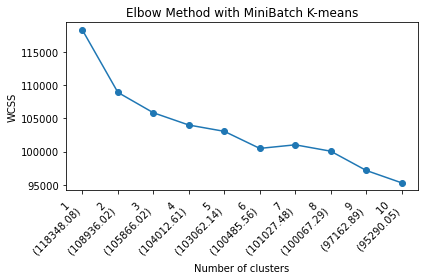

In [17]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])

data_for_clustering = df_scd.drop(columns=['death_label'])
data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 11):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=42)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

# 그래프 생성
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i} \n ({w:.2f})' for i, w in enumerate(wcss, 1)]
plt.xticks(range(1, 11), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

In [18]:
wcss

[118348.08209583197,
 108936.01647179166,
 105866.01886128247,
 104012.61036843562,
 103062.14151988023,
 100485.56141434085,
 101027.477058043,
 100067.29203441023,
 97162.88907827114,
 95290.05142645849]

In [ ]:
# CLUSTERING :: GMM

In [19]:
data_for_clustering = df_scd.drop(columns=['death_label']) 
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))

# 실루엣 점수 및 표준 편차 계산
print("Calculating silhouette scores and standard deviation for each cluster...")
silhouette_scores = []
silhouette_std_devs = []
range_n_clusters = list(range(2, 10))  # 클러스터 수를 2부터 10까지 시도

best_n_clusters = None
best_silhouette_avg = -1
best_silhouette_std = np.inf
best_cluster_labels = None

for n_clusters in range_n_clusters:
    # K-Means 모델과 마찬가지로 결측값을 평균으로 대체
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', init_params='kmeans'
                          , random_state=SEED, n_init=SEED
                         )
    cluster_labels = gmm.fit_predict(data_for_clustering.fillna(data_for_clustering.mean()))
    
    # silhouette_score, silhouette_samples도 같은 결측치 처리 방식 적용
    silhouette_avg = silhouette_score(data_for_clustering.fillna(data_for_clustering.mean()), cluster_labels)
    silhouette_vals = silhouette_samples(data_for_clustering.fillna(data_for_clustering.mean()), cluster_labels)
    silhouette_std_dev = np.std([
        np.mean(silhouette_vals[cluster_labels == label]) 
        for label in np.unique(cluster_labels)
    ])
    
    silhouette_scores.append(silhouette_avg)
    silhouette_std_devs.append(silhouette_std_dev)
    
    print(f"For n_clusters = {n_clusters}, Average Silhouette Score: {silhouette_avg}, Std Deviation: {silhouette_std_dev}")
    
    # 표준 편차가 가장 낮은(즉, 균일한) 클러스터 수 선택
    if silhouette_std_dev < best_silhouette_std:
        best_n_clusters = n_clusters
        best_silhouette_avg = silhouette_avg
        best_silhouette_std = silhouette_std_dev
        best_cluster_labels = cluster_labels

print("Best number of clusters based on STD DEVIATION:", best_n_clusters)
print("Cluster number of the HIGHEST silhouette score:", range_n_clusters[np.argmax(silhouette_scores)])

# 최적 GMM 모델 학습
best_gmm = GaussianMixture(n_components=best_n_clusters, covariance_type='full'
                           , random_state=SEED
                          )
best_gmm.fit(data_for_clustering.fillna(data_for_clustering.mean()))
df_scd['Cluster_Labels'] = best_cluster_labels +1

# GMM 파라미터(모델) 저장
with open(os.path.join(save_dir, "GMM_model.pkl"), "wb") as f:
    pickle.dump(best_gmm, f)

# 히트맵 시각화
def plot_heatmap(cluster_labels, method):
    sorted_idx = np.argsort(cluster_labels)
    data_sorted = data_for_clustering.iloc[sorted_idx]
    
    plt.figure(figsize=(20, 10))
    ax = sns.heatmap(data_sorted.T,
                     cmap='viridis',
                     cbar=False,
                     yticklabels=True,
                     xticklabels=False
                    )
    ax.set_xticks([])
    ax.set_xlabel('')
    plt.ylabel('Features')
    plt.title(f'Heatmap for {method}')

# death_label 컬럼 복원
df_scd['death_label'] = df['death_label']

print("Clustering completed with SCALED data.")
df_scd

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1aa9cc74c0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Index(['sex_sys_val', 'apgs1', 'apgs5', 'bwei', 'mage', 'gran', 'parn', 'bhei',
       'bheiuk', 'bhead',
       ...
       'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3', 'pvl_2', 'seps_1',
       'seps_2', 'seps_3', 'death_label'],
      dtype='object', length=112) 112
Index(['sex_sys_val', 'apgs1', 'apgs5', 'bwei', 'mage', 'gran', 'parn', 'bhei',
       'bheiuk', 'bhead',
       ...
       'oxyt36_3', 'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3',
       'pvl_2', 'seps_1', 'seps_2', 'seps_3'],
      dtype='object', length=111) 111
Calculating silhouette scores and standard deviation for each cluster...


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1922c28c10>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1922c28c10>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1922c28c10>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19226bbe50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19226bbe50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f19226bbe50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

For n_clusters = 9, Average Silhouette Score: 0.021182987026729685, Std Deviation: 0.06351665010317317
Best number of clusters based on STD DEVIATION: 2
Cluster number of the HIGHEST silhouette score: 2
Clustering completed with SCALED data.


,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3,death_label,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
3,0.893117,1.034192,0.325095,1.521074,-1.692109,-0.817740,-0.646239,0.351421,-0.327271,1.395323,...,-0.425815,-0.754548,-2.260078,12.351981,-0.431896,-1.174018,1.174018,0.0,0,2
4,0.893117,-0.016137,-0.784583,1.154606,0.556645,1.793361,0.707966,2.044964,-0.327271,0.770313,...,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0,2
44,0.893117,-1.591631,-0.784583,0.238436,-0.342857,-0.817740,-0.646239,0.492550,-0.327271,0.353640,...,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0,1
109,-1.119674,-0.541302,-1.339421,-0.010762,1.006396,0.922994,2.062171,0.633678,-0.327271,-0.896379,...,2.348436,-0.754548,-2.260078,-0.080959,2.315372,-1.174018,1.174018,0.0,0,1
134,-1.119674,0.509027,0.879934,0.201789,0.106894,0.922994,-0.646239,0.492550,-0.327271,-0.479706,...,2.348436,-0.754548,-2.260078,-0.080959,2.315372,-1.174018,1.174018,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20238,-1.119674,1.559356,1.434773,-0.677734,-0.792608,-0.817740,-0.646239,-0.495350,-0.327271,-0.271370,...,-0.425815,-0.754548,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0,2
20247,0.893117,1.559356,1.434773,1.777602,-0.792608,-0.817740,-0.646239,1.198193,-0.327271,1.603659,...,-0.425815,1.325296,0.442463,-0.080959,-0.431896,0.851776,-0.851776,0.0,0,2
20262,-1.119674,1.034192,0.879934,0.604904,-0.342857,-0.817740,-0.646239,0.633678,-0.327271,0.353640,...,2.348436,-0.754548,0.442463,-0.080959,-0.431896,-1.174018,1.174018,0.0,0,2


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f8a76796e50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

n_clusters = 4: Cluster sizes = [2 2 0 ... 1 0 1]
For n_clusters = 4,
Average Silhouette_score : 0.0678,
std deviation: 0.1205



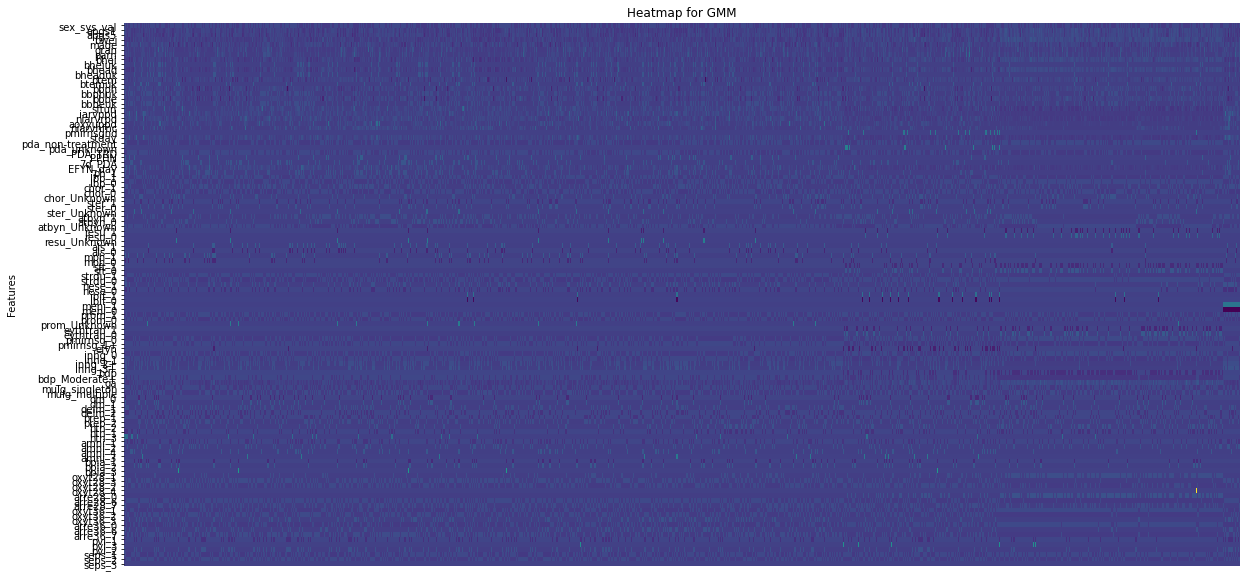

Clustering completed with 4 clusters.
          sex_sys_val     apgs1     apgs5      bwei      mage      gran  \
idx_code                                                                  
3            0.893117  1.034192  0.325095  1.521074 -1.692109 -0.817740   
4            0.893117 -0.016137 -0.784583  1.154606  0.556645  1.793361   
44           0.893117 -1.591631 -0.784583  0.238436 -0.342857 -0.817740   
109         -1.119674 -0.541302 -1.339421 -0.010762  1.006396  0.922994   
134         -1.119674  0.509027  0.879934  0.201789  0.106894  0.922994   
...               ...       ...       ...       ...       ...       ...   
20238       -1.119674  1.559356  1.434773 -0.677734 -0.792608 -0.817740   
20247        0.893117  1.559356  1.434773  1.777602 -0.792608 -0.817740   
20262       -1.119674  1.034192  0.879934  0.604904 -0.342857 -0.817740   
20308        0.893117 -0.541302  0.879934 -0.402883  0.106894  0.052627   
20312       -1.119674  0.509027  0.879934  1.227900 -0.342857 

In [17]:
## 재 클러스터링 with GMM Params : {n} Clusters
data_for_clustering = df_scd.drop(columns=['death_label'])
data_for_clustering_filled = data_for_clustering.fillna(data_for_clustering.mean())

n_clusters = 4


# 저장된 GMM 모델 로드
with open(os.path.join(save_dir, "GMM_model.pkl"), "rb") as f:
    best_gmm = pickle.load(f)

# 파라미터 추출 (기존 모델)
old_params = best_gmm.get_params()

# component 수(n_components)만 원하는 값으로 변경, 나머지는 동일하게 유지
new_params = copy.deepcopy(old_params)
new_params['n_components'] = n_clusters

# 새로운 GMM 모델 생성
gmm_new = GaussianMixture(**new_params)

# 새 모델 학습 & 예측 (fit_predict)
cluster_labels_new = gmm_new.fit_predict(data_for_clustering_filled)
df_scd['Cluster_Labels'] = cluster_labels_new +1

# 각 클러스터에 할당된 샘플 수 확인
unique, counts = np.unique(cluster_labels_new, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_labels_new}")

# 실루엣 점수 계산
silhouette_vals = silhouette_samples(data_for_clustering_filled, cluster_labels_new)
silhouette_avg = np.mean(silhouette_vals)
silhouette_std_dev = np.std([
    np.mean(silhouette_vals[cluster_labels_new == label]) 
    for label in np.unique(cluster_labels_new)
])

# 실루엣 점수 및 표준 편차 출력
print(f"For n_clusters = {n_clusters},\n"
      f"Average Silhouette_score : {silhouette_avg:.4f},\n"
      f"std deviation: {silhouette_std_dev:.4f}\n")

# 히트맵 시각화 함수
def plot_heatmap(cluster_labels_new, method):
    sorted_idx = np.argsort(cluster_labels_new)
    data_sorted = data_for_clustering.iloc[sorted_idx]
    
    plt.figure(figsize=(20, 10))
    ax = sns.heatmap(data_sorted.T,
                     cmap='viridis',
                     cbar=False,
                     yticklabels=True,
                     xticklabels=False
                    )
    ax.set_xticks([])
    ax.set_xlabel('')
    plt.ylabel('Features')
    plt.title(f'Heatmap for {method}')
    plt.show()

plot_heatmap(cluster_labels_new, "GMM")

# death_label 컬럼 복원
df_scd['death_label'] = df['death_label']

print(f"Clustering completed with {n_clusters} clusters.")
print(df_scd)

In [18]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1    692
2    152
3    214
4     17
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
apgs1             0
apgs5             0
bwei              0
mage              0
                 ..
seps_1            0
seps_2            0
seps_3            0
death_label       0
Cluster_Labels    0
Length: 113, dtype: int64


In [19]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [20]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,6.0,7.0,1340,26,1,0,36.0,0.0,28.0,...,0,1,0,0,0,1,0,0,0,3
4,1,4.0,5.0,1240,36,4,1,42.0,0.0,26.5,...,0,1,0,0,0,1,0,0,0,3
44,1,1.0,5.0,990,32,1,0,36.5,0.0,25.5,...,0,1,0,0,0,1,0,0,0,1
109,0,3.0,4.0,922,38,3,2,37.0,0.0,22.5,...,0,0,1,0,0,0,1,0,0,1
134,0,5.0,8.0,980,34,3,0,36.5,0.0,23.5,...,0,1,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20238,0,7.0,9.0,740,30,1,0,33.0,0.0,24.0,...,0,0,1,0,0,0,0,1,0,1
20247,1,7.0,9.0,1410,30,1,0,39.0,0.0,28.5,...,0,1,0,0,0,1,0,0,0,2
20262,0,6.0,8.0,1090,32,1,0,37.0,0.0,25.5,...,0,0,0,0,1,1,0,0,0,2


In [21]:
df_combined.to_csv(os.path.join(save_dir, "KNN_df_combined.csv"))

In [22]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                    Cluster 1                     Cluster 2  \
sex_sys_val            0.5650 ± 0.4961 (n.s.)        0.5197 ± 0.5013 (n.s.)   
apgs1            3.6706 ± 1.7464 (6.5686e-16)        4.0214 ± 1.9575 (n.s.)   
apgs5            6.1234 ± 1.7334 (1.0539e-13)        6.4459 ± 1.9109 (n.s.)   
bwei         837.1734 ± 225.3465 (4.0695e-42)    972.3092 ± 274.9507 (n.s.)   
mage                  33.4639 ± 4.5641 (n.s.)       33.3487 ± 4.0921 (n.s.)   
...                                       ...                           ...   
iperr_4              0.0000 ± 0.0000 (0.0071)  0.0263 ± 0.1606 (8.0564e-07)   
iperroy_1        0.6705 ± 0.4704 (1.2085e-05)        0.7434 ± 0.4382 (n.s.)   
iperroy_4              0.0332 ± 0.1794 (n.s.)        0.0329 ± 0.1790 (n.s.)   
iperroy_3        0.2890 ± 0.4536 (1.3964e-05)        0.2105 ± 0.4090 (n.s.)   
iperroy_2              0.0072 ± 0.0848 (n.s.)        0.0132 ± 0.1143 (n.s.)   

   

In [23]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

In [24]:
## Main FEATURE RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'death_label')
cmr1 = calculate_positive_rate(df_combined, 'ntet_1')
cmr2 = calculate_positive_rate(df_combined, 'iperr_2')
print(cmr, cmr1, cmr2)

           Total  death_Pos  death_Neg Positive Rate death_Pos / Total
Cluster 1  692.0        0.0      692.0         0.00%           0 / 692
Cluster 2  152.0        0.0      152.0         0.00%           0 / 152
Cluster 3  214.0        0.0      214.0         0.00%           0 / 214
Cluster 4   17.0        0.0       17.0         0.00%            0 / 17            Total  ntet_Pos  ntet_Neg Positive Rate ntet_Pos / Total
Cluster 1  692.0     525.0     167.0        75.87%        525 / 692
Cluster 2  152.0     129.0      23.0        84.87%        129 / 152
Cluster 3  214.0     186.0      28.0        86.92%        186 / 214
Cluster 4   17.0      12.0       5.0        70.59%          12 / 17            Total  iperr_Pos  iperr_Neg Positive Rate iperr_Pos / Total
Cluster 1  692.0      228.0      464.0        32.95%         228 / 692
Cluster 2  152.0       39.0      113.0        25.66%          39 / 152
Cluster 3  214.0       34.0      180.0        15.89%          34 / 214
Cluster 4   17.0     

In [25]:
cmr.to_csv(os.path.join(save_dir, "mortality_rate_results_mortality.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "mortality_rate_results_ntetPos.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "mortality_rate_results_iperrPos.csv"), encoding='utf-8-sig')

In [26]:
# Result function : 'n' about 2+ Cols

def calculate_positive_rate(ipt_df, ipt_cols):
    # 'Cluster_Labels'와 ipt_cols가 존재하는지 확인
    if 'Cluster_Labels' in ipt_df.columns and all(col in ipt_df.columns for col in ipt_cols):
        results_df = pd.DataFrame()

        # 두 칼럼 전부 1인 경우를 Positive로 간주 ('And' Condition)
        ipt_df['combined_Positive'] = (ipt_df[ipt_cols[0]] == 1) & (ipt_df[ipt_cols[1]] == 1)

        # 각 클러스터별 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = cluster_data['combined_Positive'].sum()
            negative_count = total_count - positive_count

            # 칼럼 이름 조합하여 표시
            display_col = "_and_".join([col.split('_')[0] for col in ipt_cols])

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 'combined_Positive' 칼럼 삭제 (원본 유지)
        ipt_df.drop(columns=['combined_Positive'], inplace=True)

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and {ipt_cols}"

# 사용 예시
cmr3 = calculate_positive_rate(df_combined, ['ntet_1', 'iperr_2'])
print(cmr3)

           Total  ntet_and_iperr_Pos  ntet_and_iperr_Neg Positive Rate  \
Cluster 1  692.0                61.0               631.0         8.82%   
Cluster 2  152.0                16.0               136.0        10.53%   
Cluster 3  214.0                 6.0               208.0         2.80%   
Cluster 4   17.0                 0.0                17.0         0.00%   

          ntet_and_iperr_Pos / Total  
Cluster 1                   61 / 692  
Cluster 2                   16 / 152  
Cluster 3                    6 / 214  
Cluster 4                     0 / 17  


In [27]:
cmr3.to_csv(os.path.join(save_dir, "mortality_rate_results_iperr&ntet.csv"), encoding='utf-8-sig')